# 02 — Model Comparison & Evaluation

**Author:** Virginia Galván, PhD

The SQL-assembled cohort produced in Notebook 01 (`brca_pam50_cohort.csv`) is loaded and used to compare three classifiers — Logistic Regression, Random Forest, and XGBoost — via stratified cross-validation on the PAM50 subtype prediction task. The best-performing model is evaluated on a held-out test set, and the fitted model is exported for the API in Notebook/step 04.

Designed to run in Google Colab or locally, after Notebook 01.

In [1]:
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

IN_COLAB = "google.colab" in str(get_ipython())
DATA_DIR = "." if IN_COLAB else "../data"
FIGURES_DIR = "." if IN_COLAB else "../figures"
API_DIR = "." if IN_COLAB else "../api"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(API_DIR, exist_ok=True)

RANDOM_STATE = 42

**Required input:** `brca_pam50_cohort.csv`, produced by Notebook 01. Run the cell below to upload it (Colab only — if running locally, place it in `../data/`).

In [2]:
if IN_COLAB:
    from google.colab import files
    print("Upload brca_pam50_cohort.csv:")
    files.upload()

Upload brca_pam50_cohort.csv:


Saving brca_pam50_cohort.csv to brca_pam50_cohort.csv


## 1. Load cohort

The SQL-assembled cohort from Notebook 01 is loaded directly — no further filtering needed, since cohort assembly already happened via SQL.

In [3]:
csv_path = os.path.join(DATA_DIR, "brca_pam50_cohort.csv")
cohort = pd.read_csv(csv_path)

PAM50_GENES = [c for c in cohort.columns if c not in ("SAMPLE_ID", "PATIENT_ID", "SUBTYPE")]

f"{len(cohort)} rows loaded"

'981 rows loaded'

## 2. Train/test split

An 80/20 split, stratified by subtype so that the class imbalance observed in Notebook 01 is preserved proportionally in both sets.

In [4]:
X = cohort[PAM50_GENES]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(cohort["SUBTYPE"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
pd.Series(label_encoder.inverse_transform(y_train)).value_counts()

Train: 784 samples | Test: 197 samples


,count
LumA,399
LumB,157
Basal,137
Her2,62
Normal,29


## 3. Model comparison via cross-validation

Logistic Regression, Random Forest, and XGBoost are compared with 5-fold stratified cross-validation on the training set. Class imbalance is corrected the same way for all three models — via per-sample weights (`compute_sample_weight("balanced", ...)`) passed at fit time — so the comparison isn't confounded by each model handling imbalance differently.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = {name: {"accuracy": [], "f1_macro": [], "roc_auc_ovr": []} for name in models}

for train_idx, val_idx in cv.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    fold_sample_weight = compute_sample_weight("balanced", y_fold_train)

    for name, model in models.items():
        fold_model = clone(model)
        fold_model.fit(X_fold_train, y_fold_train, sample_weight=fold_sample_weight)
        y_fold_pred = fold_model.predict(X_fold_val)
        y_fold_proba = fold_model.predict_proba(X_fold_val)

        cv_scores[name]["accuracy"].append(accuracy_score(y_fold_val, y_fold_pred))
        cv_scores[name]["f1_macro"].append(f1_score(y_fold_val, y_fold_pred, average="macro"))
        cv_scores[name]["roc_auc_ovr"].append(
            roc_auc_score(y_fold_val, y_fold_proba, multi_class="ovr")
        )

cv_results_df = pd.DataFrame(
    {name: {metric: np.mean(values) for metric, values in scores.items()}
     for name, scores in cv_scores.items()}
).T
cv_results_df

,accuracy,f1_macro,roc_auc_ovr
Logistic Regression,0.834191,0.776357,0.964218
Random Forest,0.896742,0.806316,0.989420
XGBoost,0.912053,0.857583,0.988842


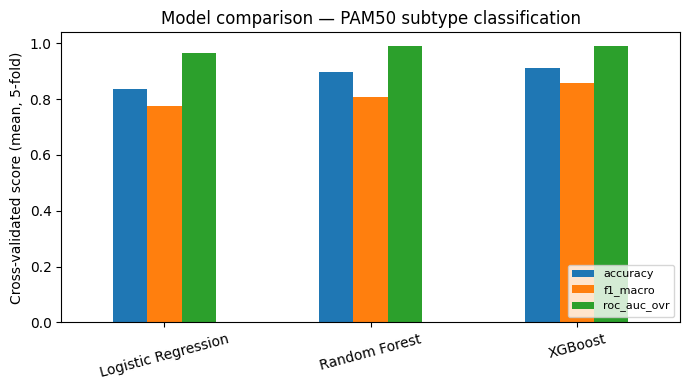

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
cv_results_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Cross-validated score (mean, 5-fold)")
ax.set_title("Model comparison — PAM50 subtype classification")
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig5_model_comparison_cv.png"), dpi=150)
plt.show()

## 4. Final model — fit, test evaluation, export

The model with the highest mean cross-validated F1-macro is refit on the full training set and evaluated once on the held-out test set.

In [7]:
best_model_name = cv_results_df["f1_macro"].idxmax()
best_model = models[best_model_name]

sample_weight_train = compute_sample_weight("balanced", y_train)
best_model.fit(X_train, y_train, sample_weight=sample_weight_train)

best_model_name

'XGBoost'

              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        34
        Her2       0.88      0.94      0.91        16
        LumA       0.93      0.94      0.94       100
        LumB       0.87      0.85      0.86        40
      Normal       1.00      0.86      0.92         7

    accuracy                           0.93       197
   macro avg       0.94      0.92      0.93       197
weighted avg       0.93      0.93      0.93       197



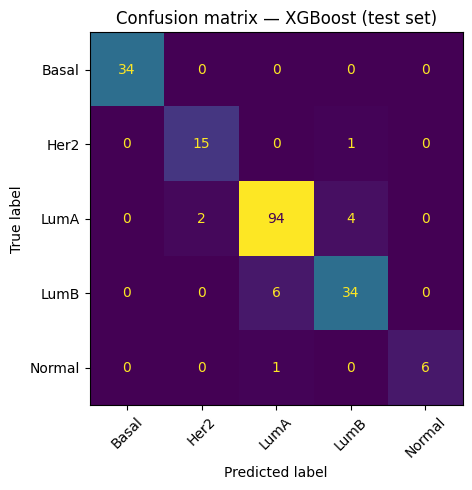

In [8]:
y_pred = best_model.predict(X_test)

print(classification_report(
    y_test, y_pred, target_names=label_encoder.classes_
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=label_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False,
)
ax.set_title(f"Confusion matrix — {best_model_name} (test set)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig6_confusion_matrix_test.png"), dpi=150)
plt.show()

## 5. Export trained model

The fitted model, the PAM50 gene order it expects as input, and the subtype label encoder are saved together, so the API in the next step can load one artifact and reproduce predictions exactly.

In [9]:
model_bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_order": PAM50_GENES,
    "label_encoder": label_encoder,
}

model_path = os.path.join(API_DIR, "model.joblib")
joblib.dump(model_bundle, model_path)
model_path

'./model.joblib'